In [1]:
import re
import json
import glob

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import scienceplots
plt.style.use(["ieee", "no-latex"])
plt.rcParams["figure.dpi"] = 300

## Metrics

In [ ]:
df = pd.concat([pd.read_csv(x) for x in glob.glob("../data/evals/*.csv")], ignore_index=True)
df["model"] = df["model"].str.split("/").str[-1].str.replace("-stem", "").str.replace(".joblib", "").str.replace("ams-tf", "_ams-tf").str.replace("ams-bow", "_ams-bow")

df.head()

,model,stemming_model,stemming_eval,metric,k,value
0,ams-multi-qa-MiniLM-L6-cos-v1,True,False,NDCG,1,0.15298
1,ams-multi-qa-MiniLM-L6-cos-v1,True,False,NDCG,3,0.20772
2,ams-multi-qa-MiniLM-L6-cos-v1,True,False,NDCG,5,0.22686
3,ams-multi-qa-MiniLM-L6-cos-v1,True,False,NDCG,10,0.25014
4,ams-multi-qa-MiniLM-L6-cos-v1,True,False,NDCG,100,0.29568


In [8]:
df.to_csv("../data/eval-all.csv", index=False, sep=";", decimal=",")

In [5]:
dd = df[(df["k"] == 5) & (~df["stemming_eval"])].pivot_table(index=["stemming_model", "model"], columns=["metric"], values="value")
dd

metric                                                               MAP  \
stemming_model model                                                       
False          ../models/ams-all-mpnet-base-v2                   0.25503   
               ../models/ams-msmarco-MiniLM-L6-cos-v5            0.20951   
               ../models/ams-msmarco-distilbert-cos-v5           0.25513   
               ../models/ams-multi-qa-MiniLM-L6-cos-v1           0.21844   
               ../models/ams-multi-qa-distilbert-cos-v1          0.26283   
               ../models/ams-tf-idf.joblib                       0.50750   
               sentence-transformers/all-mpnet-base-v2           0.13347   
               sentence-transformers/msmarco-MiniLM-L6-cos-v5    0.12065   
               sentence-transformers/msmarco-distilbert-cos-v5   0.07675   
               sentence-transformers/multi-qa-MiniLM-L6-cos-v1   0.14309   
               sentence-transformers/multi-qa-distilbert-cos-v1  0.13082   
True           ../models/ams-all-mpnet-base-v2-stem              0.24492   
               ../models/ams-bow-stem.joblib                     0.31391   
               ../models/ams-msmarco-MiniLM-L6-cos-v5-stem       0.18705   
               ../models/ams-msmarco-distilbert-cos-v5-stem      0.23069   
               ../models/ams-multi-qa-MiniLM-L6-cos-v1-stem      0.20490   
               ../models/ams-multi-qa-distilbert-cos-v1-stem     0.24492   
               ../models/ams-tf-idf-stem.joblib                  0.50750   

metric                                                              NDCG  \
stemming_model model                                                       
False          ../models/ams-all-mpnet-base-v2                   0.27966   
               ../models/ams-msmarco-MiniLM-L6-cos-v5            0.22959   
               ../models/ams-msmarco-distilbert-cos-v5           0.27938   
               ../models/ams-multi-qa-MiniLM-L6-cos-v1           0.24216   
               ../models/ams-multi-qa-distilbert-cos-v1          0.28750   
               ../models/ams-tf-idf.joblib                       0.54795   
               sentence-transformers/all-mpnet-base-v2           0.14865   
               sentence-transformers/msmarco-MiniLM-L6-cos-v5    0.13345   
               sentence-transformers/msmarco-distilbert-cos-v5   0.08472   
               sentence-transformers/multi-qa-MiniLM-L6-cos-v1   0.15852   
               sentence-transformers/multi-qa-distilbert-cos-v1  0.14559   
True           ../models/ams-all-mpnet-base-v2-stem              0.27054   
               ../models/ams-bow-stem.joblib                     0.34536   
               ../models/ams-msmarco-MiniLM-L6-cos-v5-stem       0.20744   
               ../models/ams-msmarco-distilbert-cos-v5-stem      0.25273   
               ../models/ams-multi-qa-MiniLM-L6-cos-v1-stem      0.22686   
               ../models/ams-multi-qa-distilbert-cos-v1-stem     0.26749   
               ../models/ams-tf-idf-stem.joblib                  0.54795   

metric                                                                 P  \
stemming_model model                                                       
False          ../models/ams-all-mpnet-base-v2                   0.07072   
               ../models/ams-msmarco-MiniLM-L6-cos-v5            0.05799   
               ../models/ams-msmarco-distilbert-cos-v5           0.07048   
               ../models/ams-multi-qa-MiniLM-L6-cos-v1           0.06280   
               ../models/ams-multi-qa-distilbert-cos-v1          0.07235   
               ../models/ams-tf-idf.joblib                       0.13379   
               sentence-transformers/all-mpnet-base-v2           0.03890   
               sentence-transformers/msmarco-MiniLM-L6-cos-v5    0.03444   
               sentence-transformers/msmarco-distilbert-cos-v5   0.02176   
               sentence-transformers/multi-qa-MiniLM-L6-cos-v1   0.04104   
               sentence-transformers/multi-qa-

## Training History

In [17]:
train_history = []

for file_path in glob.glob("../data/train-*.log"):
    with open(file_path, "r") as f:
        current_run = {}
        for line in f:
            if line.startswith("Namespace"):
                current_run["model"] = re.search(r"model_name='(.+?)'", line).group(1)[22:]
                current_run["stemming"] = "stemming=True" in line

            if line.startswith("{'loss':"):
                parsed = json.loads(line.replace("'", "\""))
                train_history.append({
                    **current_run,
                    "epoch": parsed["epoch"],
                    "loss": parsed["loss"],
                })

df_history = pd.DataFrame(train_history)
df_history.head()

,model,stemming,epoch,loss
0,all-mpnet-base-v2,True,0.53,0.9565
1,all-mpnet-base-v2,True,1.07,0.6731
2,all-mpnet-base-v2,True,1.60,0.5445
3,all-mpnet-base-v2,True,2.13,0.4549
4,all-mpnet-base-v2,True,2.67,0.3075


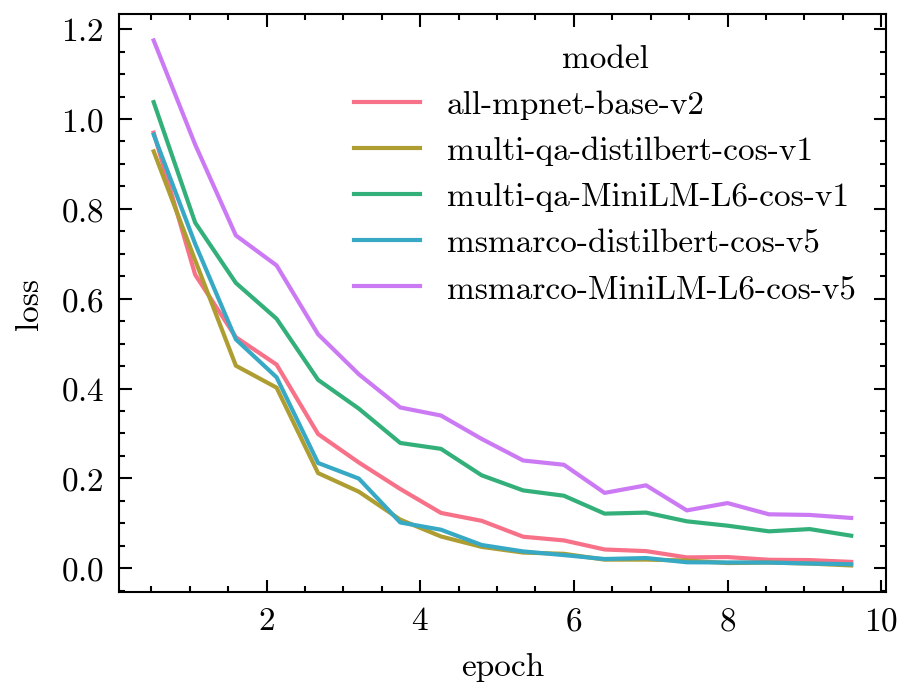

In [18]:
sns.lineplot(df_history[df_history["stemming"] == False], x="epoch", y="loss", hue="model")
plt.show()

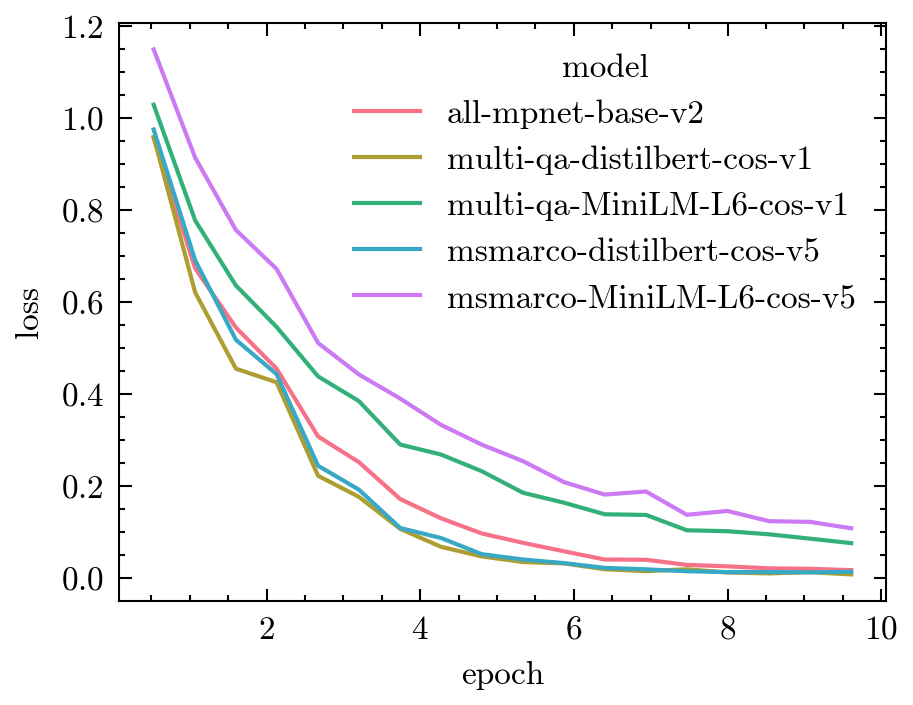

In [19]:
sns.lineplot(df_history[df_history["stemming"] == True], x="epoch", y="loss", hue="model")
plt.show()